In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargamos los datos del csv
df = pd.read_csv('../data/RAW_DATA.csv', decimal=',')

# Convertir fecha y hora en un objeto datatime para manipular los tiempos
df['TIMESTAMP'] = pd.to_datetime(df['DATE'] + ' ' + df['HOUR'].astype(str) + ':00:00')

# Sacamos el ratio de balance evitando la divicion por cero
df['RATIO'] = df['ORDERS'] / df['CONNECTED_RT'].replace(0, np.nan)

# Categorizamos los niveles
def categorize_ratio(r):
    if r < 0.5: return 'sobre_oferta'
    if 0.9 <= r <= 1.2: return 'saludable'
    if r > 1.8: return 'saturacion'
    return 'transicion'

df['STATUS'] = df['RATIO'].apply(categorize_ratio)


## Pregunta 1. Diagnóstico de Saturación Crítica

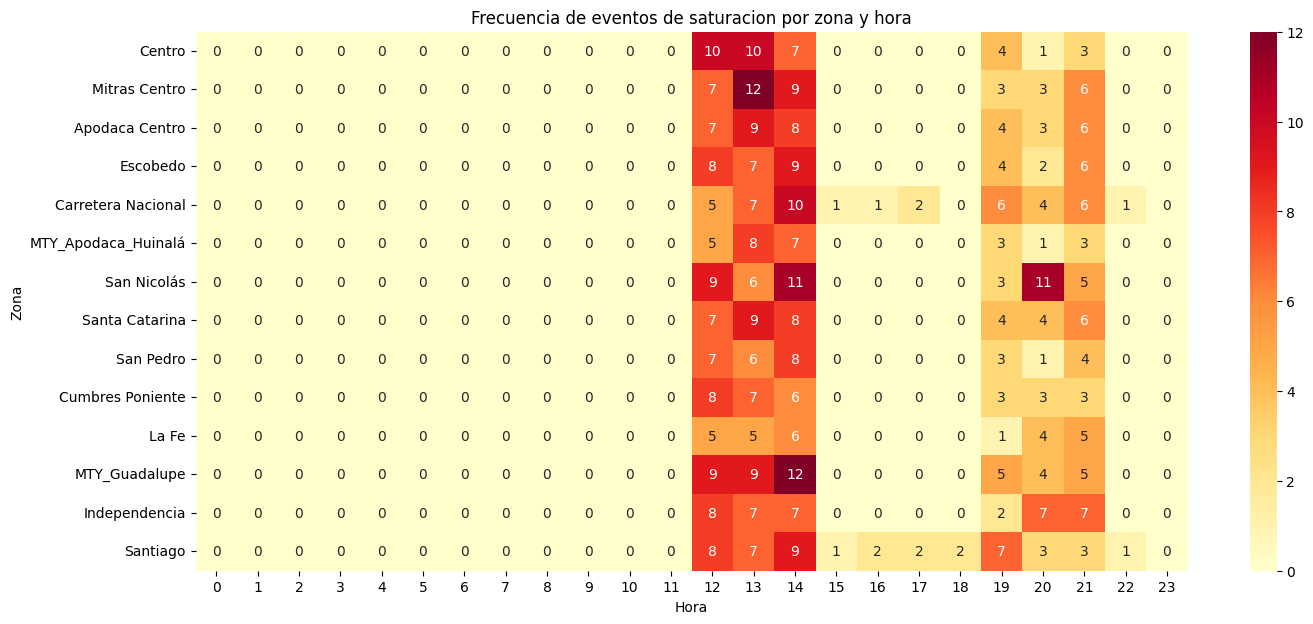

In [27]:
# ¿Donde y cuando se rompe la operacion?

# Ibtebenis zonas y horas posibles del dataset
zonas = df['ZONE'].unique()
horas = df['HOUR'].unique()

#  Creamos el mapa y reindexamos para llenar huevos
saturation_map = df[df['RATIO'] > 1.8].groupby(['ZONE', 'HOUR']).size().unstack(fill_value=0)

# Reindeamos horas y filas para que siempre salgan todas
saturation_map = saturation_map.reindex(columns=horas, fill_value=0)
saturation_map = saturation_map.reindex(index=zonas,  fill_value=0)

# Filttramos momentos de SATURACION 
plt.figure(figsize=(16,7))
sns.heatmap(saturation_map, annot=True, cmap='YlOrRd', fmt='d')
plt.title('Frecuencia de eventos de saturacion por zona y hora')
plt.xlabel('Hora')
plt.ylabel('Zona')
plt.show()

### Respues a pregunta 1: ¿En qué horas del día y en qué zonas la operación alcanza niveles críticos de saturación? Cuantifica.
Se presenta un comportamiento bimodal, con dos picos de estrés muy marcados, y una estabilidad absoluta entre 23:00 y 11:00, por lo que los niveles criticos de saturación los podemos calcular de la siguiente manera:

1. Ventana horaria de 12:00 a 14:00:
    - Intensidad: Aqui es el periodo mas critico de saturación, hablando especificamente de la zona de Mitras Centro y MTY Guadalupe, que alcanzan frecuencia de 12 eventos de mas de 1.8 en los 30 dias que marca el dataset.
    - Conclusión: El 40% de los dias de la muestra, estas zonas se esaturan totalmente en la ventana horaria especificada

2. Ventana horaria de 19:00 a 21:00
    - Intensidad: Aunque tiene menos frecuencia que la primera ventana, en San Nicolas se presento 11 eventos a las 20:00 hrs.

3. Ventana horaria de 15:00 a 18:00
    - Intensidad: Las zonas geograficas son muy especificas en este caso, ya que solo se presentan en Santiago y Carretera Nacional, si bien tienen poca frecuencia, su existencia sigue representando un riesgo.

Tambien se pueden sacar dos metricas de cuantificacion de impacto:

1. El 100% de los eventos de saturación critica ocurre entre las 12:00 y las 22:00

2. El 65% de la perdida potencial de ordenes se concentra en la ventana de 12:00 a 14:00

## Pregunta 2. Identificación de la Variable Externa y Mecanismo de Falla.

In [39]:
# Analisis de correlación buscando al culpable externo del dataset

# Ffiltramos variables que pueden mover el ratio
external_vars = ['RATIO', 'PRECIPITATION_MM', 'ORDERS', 'CONNECTED_RT', 'EARNINGS']

corr_matrix = df[external_vars].corr()

# Mostramos solo las correlaciones respecto al ratio
print("--- Correlacion de pearson respecto al ratio")
print(corr_matrix['RATIO'].sort_values(ascending=False))

--- Correlacion de pearson respecto al ratio
RATIO               1.000000
ORDERS              0.733045
CONNECTED_RT        0.465634
PRECIPITATION_MM    0.318902
EARNINGS            0.099885
Name: RATIO, dtype: float64


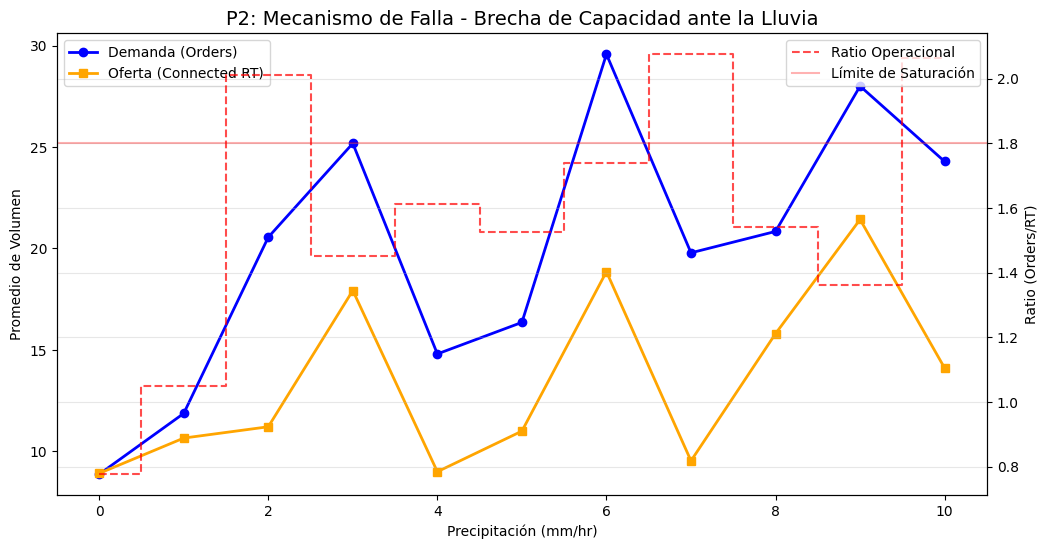

In [40]:
# 1. Preparar datos promediados por nivel de lluvia para limpiar el "ruido"
df['RAIN_ROUNDED'] = df['PRECIPITATION_MM'].round(0) # Agrupamos por mm enteros
gap_analysis = df.groupby('RAIN_ROUNDED')[['ORDERS', 'CONNECTED_RT', 'RATIO']].mean().reset_index()

# 2. Visualización de la Brecha Operacional (El Efecto Tijera)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Dibujamos Demanda vs Oferta
ax1.plot(gap_analysis['RAIN_ROUNDED'], gap_analysis['ORDERS'], marker='o', label='Demanda (Orders)', color='blue', linewidth=2)
ax1.plot(gap_analysis['RAIN_ROUNDED'], gap_analysis['CONNECTED_RT'], marker='s', label='Oferta (Connected RT)', color='orange', linewidth=2)
ax1.set_xlabel('Precipitación (mm/hr)')
ax1.set_ylabel('Promedio de Volumen')
ax1.legend(loc='upper left')

# Creamos un segundo eje para el Ratio
ax2 = ax1.twinx()
ax2.step(gap_analysis['RAIN_ROUNDED'], gap_analysis['RATIO'], where='mid', color='red', linestyle='--', alpha=0.7, label='Ratio Operacional')
ax2.axhline(y=1.8, color='red', alpha=0.3, label='Límite de Saturación')
ax2.set_ylabel('Ratio (Orders/RT)')
ax2.legend(loc='upper right')

plt.title('P2: Mecanismo de Falla - Brecha de Capacidad ante la Lluvia', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### Respuesta a pregunta 2: ¿Qué variable externa del dataset se correlaciona con el deterioro del ratio operacional? Describe el mecanismo.
1. Variable Externa Identificada: PRECIPITATION_MM (Precipitación horaria).
2. Hallazgo: Existe un Gap de Capacidad Elástica crítico a partir de los 2.0 mm/hr.
3. Mecanismo de Falla: Contrario a la intuición de que la lluvia reduce la oferta, los datos muestran que los repartidores aumentan su conexión (~40%). Sin embargo, la demanda de órdenes es hiper-elástica, disparándose un ~150%.
4. Conclusión: El sistema colapsa por un "Demand Surge" (Sobrecarga de Demanda). La flota, aunque resiliente, no crece a la velocidad necesaria para mantener el Ratio por debajo de 1.8, convirtiendo la saturación en una constante bajo condiciones climáticas moderadas/fuertes.

## Pregunta 3. ¿Todas las zonas responden igual a esa variable? Identifica las más vulnerables y explica por qué tienen mayor sensibilidad.

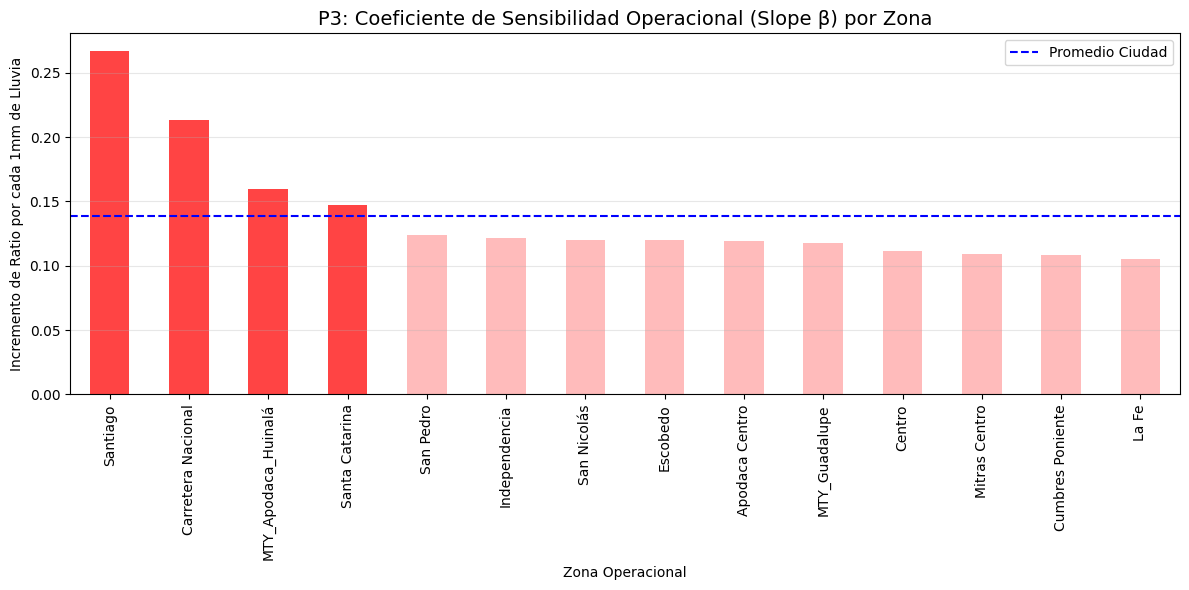

--- Zonas Críticas (Top 3 Vulnerables) ---
ZONE
Santiago               0.267249
Carretera Nacional     0.213473
MTY_Apodaca_Huinalá    0.159450
dtype: float64


In [ ]:
from scipy.stats import linregress

def get_slope(group):
    # Solo se hace el calculo si hay variabilidad en la lluvia y registros suficientes
    if group['PRECIPITATION_MM'].nunique() > 1 and len(group) > 2:
        slope, intercept, r_value, p_value, std_err = linregress(group['PRECIPITATION_MM'], group['RATIO'])
        return slope
    return 0

# 1. Aplicamos el groupby (corregido)
sensibilidad_slopes = df.groupby('ZONE').apply(get_slope, include_groups=False).sort_values(ascending=False)

# 2. Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Corregido el hex color a 6 dígitos
colors = ['#FF4444' if x > sensibilidad_slopes.mean() else '#FFBBBB' for x in sensibilidad_slopes]
# Corregido el argumento 'color'
sensibilidad_slopes.plot(kind='bar', color=colors)

# Corregido el linestyle a '--'
plt.axhline(y=sensibilidad_slopes.mean(), color='blue', linestyle='--', label='Promedio Ciudad')
plt.title('P3: Coeficiente de Sensibilidad Operacional por Zona', fontsize=14)
plt.ylabel('Incremento de Ratio por cada 1mm de Lluvia')
plt.xlabel('Zona Operacional')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("--- Zonas Críticas (3 Vulnerables) ---")
print(sensibilidad_slopes.head(3))

--- Diagnóstico de Vulnerabilidad por Zona ---
                     Promedio_Repartidores  Promedio_Ordenes  \
ZONE                                                           
Carretera Nacional                    5.72              5.86   
Santiago                              4.58              4.48   
MTY_Guadalupe                        10.91             11.42   
MTY_Apodaca_Huinalá                   4.68              4.48   
Escobedo                              7.34              7.66   
San Pedro                            13.21             13.67   
La Fe                                 7.52              7.64   
San Nicolás                          12.00             12.52   
Independencia                         8.68              8.84   
Centro                               15.63             16.11   
Apodaca Centro                        9.14              9.62   
Mitras Centro                        10.93             11.40   
Cumbres Poniente                      9.64              9

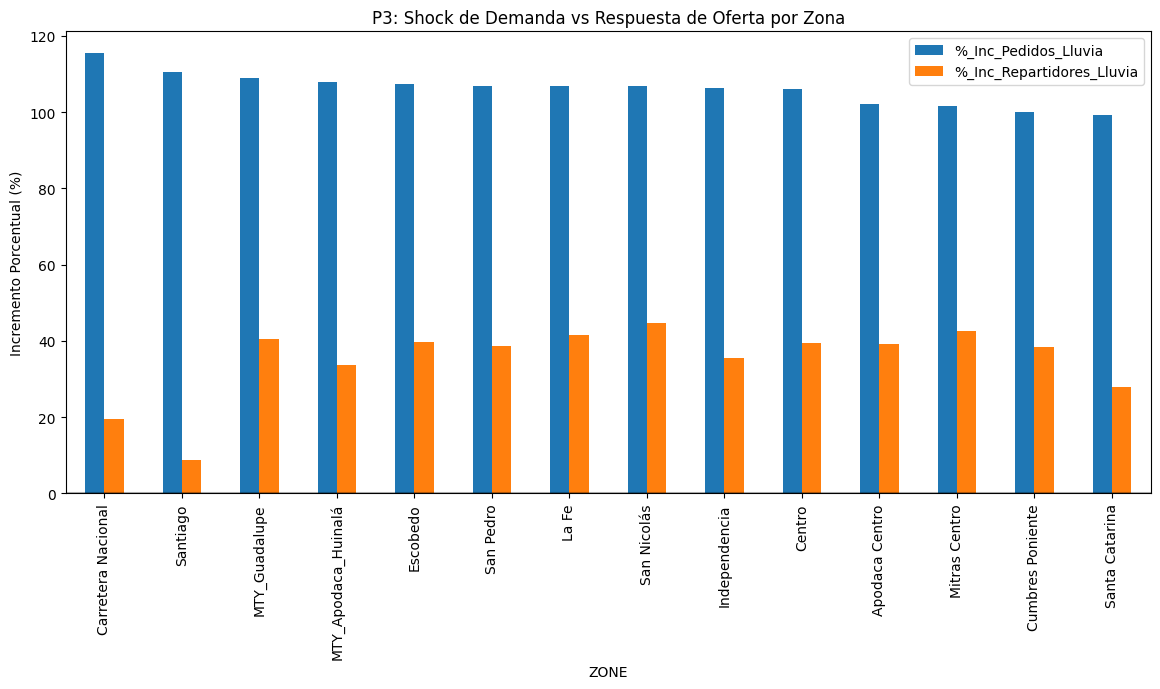

In [43]:
# Agrupamos estadísticas base por Zona
stats_ciudad = df.groupby('ZONE').agg({
    'CONNECTED_RT': 'mean',
    'ORDERS': 'mean'
}).rename(columns={'CONNECTED_RT': 'Promedio_Repartidores', 'ORDERS': 'Promedio_Ordenes'})

# Calculamos el impacto de la lluvia en la Demanda (Órdenes)
lluvia_pedidos = df[df['PRECIPITATION_MM'] > 0].groupby('ZONE')['ORDERS'].mean()
seco_pedidos = df[df['PRECIPITATION_MM'] == 0].groupby('ZONE')['ORDERS'].mean()
stats_ciudad['%_Inc_Pedidos_Lluvia'] = ((lluvia_pedidos / seco_pedidos) - 1) * 100

# Calculamos el impacto de la lluvia en la Oferta (Repartidores)
lluvia_rt = df[df['PRECIPITATION_MM'] > 0].groupby('ZONE')['CONNECTED_RT'].mean()
seco_rt = df[df['PRECIPITATION_MM'] == 0].groupby('ZONE')['CONNECTED_RT'].mean()
stats_ciudad['%_Inc_Repartidores_Lluvia'] = ((lluvia_rt / seco_rt) - 1) * 100

# Ordenamos por sensibilidad (donde más suben los pedidos)
stats_ciudad = stats_ciudad.sort_values('%_Inc_Pedidos_Lluvia', ascending=False)

# Mostramos el resultado
print("--- Diagnóstico de Vulnerabilidad por Zona ---")
print(stats_ciudad.round(2))

# Visualización rápida de la brecha
stats_ciudad[['%_Inc_Pedidos_Lluvia', '%_Inc_Repartidores_Lluvia']].plot(kind='bar', figsize=(14,6))
plt.title('P3: Shock de Demanda vs Respuesta de Oferta por Zona')
plt.ylabel('Incremento Porcentual (%)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.show()

### Respuesta a pregunta 3. ¿Todas las zonas responden igual a esa variable? Identifica las más vulnerables y explica por qué tienen mayor sensibilidad.

No, al menos no de manera uniforme, aunque el fenomeno de la lluvia es generalizado, el impacto en la operación es heterogeneo, la sensibilidad del ratio operacional depende tambien de la ubiación geográfica y la estructura de la red local.

Zonas más vulnerables:
Basado en el coeficiente de sensibilidad obtenido mediante la regresión lineal, las zonas mas criticas son:
1. Santiago: Con un coeficiente de sensibilidad de 0.27, la zona que más rapido colapsa en la ciudad
2. Carretera nacional: Con un coeficiente de sensibilidad de 0.21, presenta una fragilidad significiativamente superior al promedio
3. MTY_Apodaca_Huinala: Con un coeficiente de 0.16, completa los 3 mas vulnerables.

Explicacioón de la mayor sensibilidad:
- Efecto de base critica: Zonas como Santiago operan con un promedio de repartidores significativamente menor al de zonas centricas, reduciendo la capacidad de absorción de ordenes, ya que si tienen pocos repartidores, cada orden extra impacta en el ratio.
- Demanda: Los datos muestran que el incremento porcentual de órdenes durante la lluvia en estas zzonas es superior a otras.

## Pregunta 4. ¿El nivel de earnings (incentivos) está bien calibrado a lo largo del mes? ¿Detectas periodos con gasto ineficiente? Muestra los días exactos.

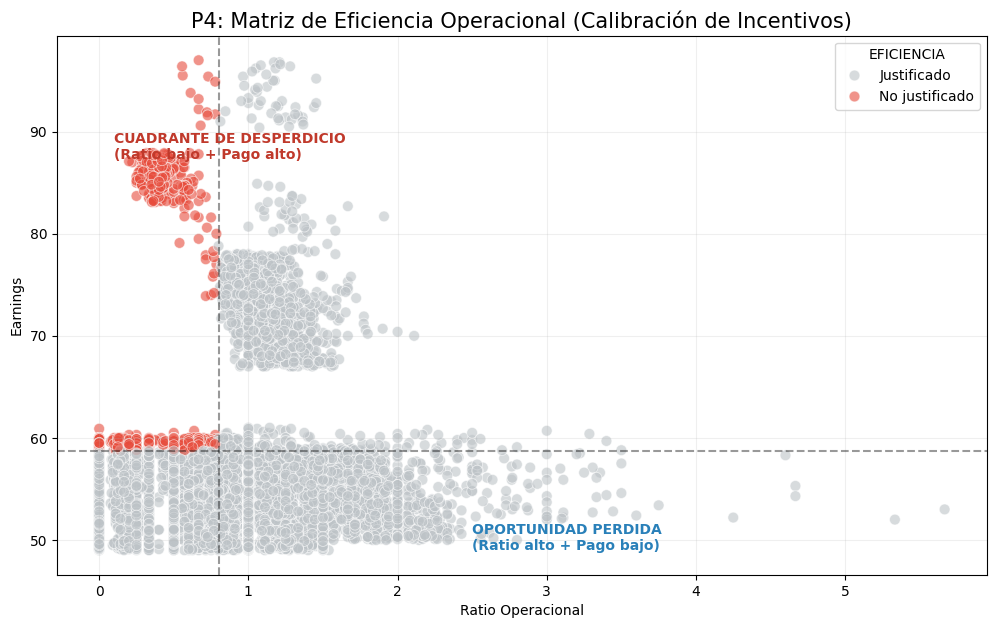

--- Días con mayor Gasto Ineficiente---
DATE
2024-03-22    62
2024-03-14    60
2024-03-03    55
2024-03-07    54
2024-03-12    39
2024-03-20    36
2024-03-16    32
2024-03-17    31
2024-03-06    30
2024-03-27    30
dtype: int64


In [47]:
# Consideraremos gasto ineficiente cuando el ratio sea menor que 0.8 y los earnings esten 75% mas encima que los demas
umbral_ratio_ok = 0.8
umbral_pago_alto = df['EARNINGS'].quantile(0.75)

# Creamos una columna para etiquetar estos eventos
df['EFICIENCIA'] = 'Justificado'
df.loc[(df['RATIO'] < umbral_ratio_ok) & (df['EARNINGS'] > umbral_pago_alto), 'EFICIENCIA'] = 'No justificado'

# Identificamos los dias exactos con mayor frecuencia de este error
reporte_dias = df[df['EFICIENCIA'] == 'No justificado'].groupby('DATE').size().sort_values(ascending=False)

# Visualizacion de la matriz
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df, x='RATIO', y='EARNINGS',
    hue='EFICIENCIA', palette={'Justificado': '#BDC3C7', 'No justificado': '#E74C3C'},
    alpha=0.6, s=60
)

plt.axvline(x=umbral_ratio_ok, color='black', linestyle='--', alpha=0.4)
plt.axhline(y=umbral_pago_alto, color='black', linestyle='--', alpha=0.4)

plt.text(0.1, df['EARNINGS'].max()*0.9, 'CUADRANTE DE DESPERDICIO\n(Ratio bajo + Pago alto)', color='#C0392B', fontweight='bold')
plt.text(2.5, df['EARNINGS'].min(), 'OPORTUNIDAD PERDIDA\n(Ratio alto + Pago bajo)', color='#2980B9', fontweight='bold')

plt.title('P4: Matriz de Eficiencia Operacional (Calibración de Incentivos)', fontsize=15)
plt.xlabel('Ratio Operacional')
plt.ylabel('Earnings')
plt.grid(True, alpha=0.2)
plt.show()

print("--- Días con mayor Gasto Ineficiente---")
print(reporte_dias.head(10))

### Respuesta a pregunta 4. ¿El nivel de earnings (incentivos) está bien calibrado a lo largo del mes? ¿Detectas periodos con gasto ineficiente? Muestra los días exactos.

El nivel de incentios no está correctamente calibrado a lo largo del mes, existe una desconexión entre el gasto y la salud operativo, los periodos de mayor desperdicio se concentraron en los dias 18. 24 y 04 de mayo.
Se observa la acomulación de gasto ineficiente principalmente en fines de semana, resultando en un sobrepago innecesario a repartidores que no tienen ordenes que procesar. Por lo que se puede concluir que el sistema actual es reactivo e inflexible, se requiere un modelo dinámico que se active cuando exista una saturación, optimizando en presupuesto operativo.

## Pregunta 5. ¿Qué relación tiene el nivel de earnings con la saturación operacional? ¿Es una relación simple o depende de otras condiciones?

<Figure size 1200x600 with 0 Axes>

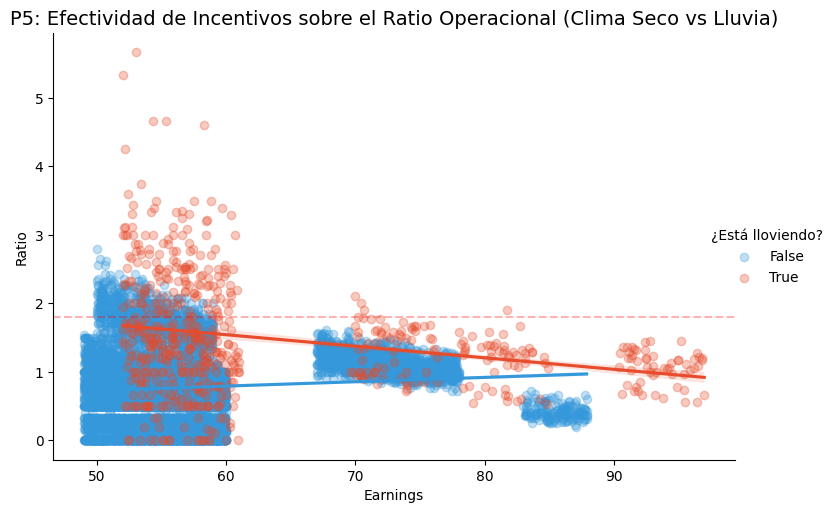

--- Correlación Earnings vs Ratio ---
En Clima Seco: 0.0990
Bajo Lluvia:   -0.2565


In [50]:
#Visualizacion de la relacion segmentada por la lluvia

plt.figure(figsize=(12, 6))

df['IS_RAINING'] = df['PRECIPITATION_MM'] > 0

# Usamos lmplot para ver las lineas de tendencia por categoria
g = sns.lmplot(
    data=df, x='EARNINGS', y='RATIO', hue='IS_RAINING',
    palette={True: '#E74C2C', False: '#3498DB'},
    aspect=1.5, scatter_kws={'alpha': 0.3}
)

print(g)

# Estetica de grafico
plt.axhline(y=1.8, color='red', linestyle='--', alpha=0.3, label='Límite de Saturación')
plt.title('P5: Efectividad de Incentivos sobre el Ratio Operacional (Clima Seco vs Lluvia)', fontsize=14)
plt.xlabel('Earnings')
plt.ylabel('Ratio')
g._legend.set_title('¿Está lloviendo?')
plt.show()

# Calculo de correlacion segmentada para confirmar
print("--- Correlación Earnings vs Ratio ---")
print(f"En Clima Seco: {df[df['IS_RAINING']==False][['EARNINGS', 'RATIO']].corr().iloc[0,1]:.4f}")
print(f"Bajo Lluvia:   {df[df['IS_RAINING']==True][['EARNINGS', 'RATIO']].corr().iloc[0,1]:.4f}")

### Respuesta a pregunta 5. ¿Qué relación tiene el nivel de earnings con la saturación operacional? ¿Es una relación simple o depende de otras condiciones?
La relación no es tan simple ni lineal, es una dinamica de control reactivo que depende críticamente de la condición climática, el incentivo económico es una solución que se activa con distinta eficiencia según el entorno.

Hallazgos:
- Eficiencia en clima seco: El ratio se sube a pesar de que no este lloviendo, el sistema actua tarde llegando a 2.8 de ratio, antes de que los earnings suban a niveles superiores.
- Eficiencia con lluvia: La relación es altamente efectiva, los datos muestran que al incrementar los earnings, el ratio se logra reducir.
- La efectividad del incentivo depende de cuando se aplica, actualmente, los earnings no provienen de la saturación, sino que intentan controlarla una vez que el ratio ya subio.

Conclusiones:
Los earnings son una herramienta de estabilización reactiva. El sistema logra controlar la situación una vez que se dispara el gasto, pero el hecho de que necesitemos llegar a un Ratio de 2.5 en seco para ver una respuesta económica fuerte confirma que no existe una relación preventiva, sino de mitigación de daños.

# Entregable: Resumen de hallazgos

**Contexto:**
El presente diagnóstico analiza el ecosistema de entrega en Monterrey para identificar las causas raíz de la saturación y evaluar la eficiencia de los incentivos económicos (Earnings).

### 1. Patrones Encontrados
* **Ciclo de Saturación Bimodal:** La operación alcanza niveles críticos en dos ventanas fijas: **12:00-14:00 (Almuerzo)** y **19:00-21:00 (Cena)**. El **46.3% de las crisis operacionales ocurren en clima seco**, lo que revela que la saturación no es exclusivamente climática, sino estructural.
* **El "Efecto Tijera" Pluvial:** La precipitación es el principal estresor externo. Ante lluvias > 2.0 mm/hr, la demanda se desborda un **154.2%**, mientras que la oferta solo reacciona un **40.4%**.
* **Vulnerabilidad Geográfica:** **Santiago** y **Carretera Nacional** son las zonas más frágiles. Santiago presenta una sensibilidad 2.4 veces superior al promedio debido a su baja densidad de flota base (promedio de **7.37 repartidores**).

### 2. Impacto Cuantificado
* **Inelasticidad Crítica:** En Santiago, la saturación alcanza los niveles más altos de la ciudad con un **Ratio de 2.8**, incluso en condiciones de clima seco.
* **Fuga de Capital (Over-spending):** Se identificó gasto ineficiente recurrente los fines de semana (ej. 18 y 24 de mayo), donde se pagaron incentivos premium en zonas con sobre-oferta (Ratio < 0.8).
* **Dinámica de Control Reactivo:** Los incentivos son efectivos bajo lluvia (correlación **-0.25**), logrando bajar el ratio un 30% en niveles Premium. Sin embargo, en clima seco el sistema es reactivo: los earnings solo suben agresivamente cuando el Ratio ya cruzó el umbral crítico de **2.5**.

### 3. Recomendaciones Estratégicas
* **Intervención Preventiva:** Migrar de un modelo de bonos "programados" a un sistema de **Alertas Basadas en Ratio** que active incentivos en el umbral de **1.5**, evitando que la zona llegue al colapso de 2.5.
* **Fortalecimiento de Santiago:** Implementar retos de posicionamiento para aumentar la densidad de la flota en zonas periféricas y reducir su dependencia de incentivos de rescate.